### Lab 10
### 10.4 Principal Components Analysis

In [6]:
import warnings

warnings.filterwarnings("ignore")

Original features
['Murder', 'Assault', 'UrbanPop', 'Rape']

Feature Means
Murder        7.79
Assault     170.76
UrbanPop     65.54
Rape         21.23
dtype: float64

Feature Variances
Murder        19.0
Assault     6945.2
UrbanPop     209.5
Rape          87.7
dtype: float64

Loading matix (Loadings / Rotation) ---
            PC1    PC2    PC3    PC4
Murder   -0.536  0.418  0.341  0.649
Assault  -0.583  0.188  0.268 -0.743
UrbanPop -0.278 -0.873  0.378  0.134
Rape     -0.543 -0.167 -0.818  0.089

Scores Matrix Shape
(50, 4)

Stadnard deviation components (sdev)
[1.591 1.005 0.603 0.421]

Portion PVE
PC1: 62.01%
PC2: 24.74%
PC3: 8.91%
PC4: 4.34%


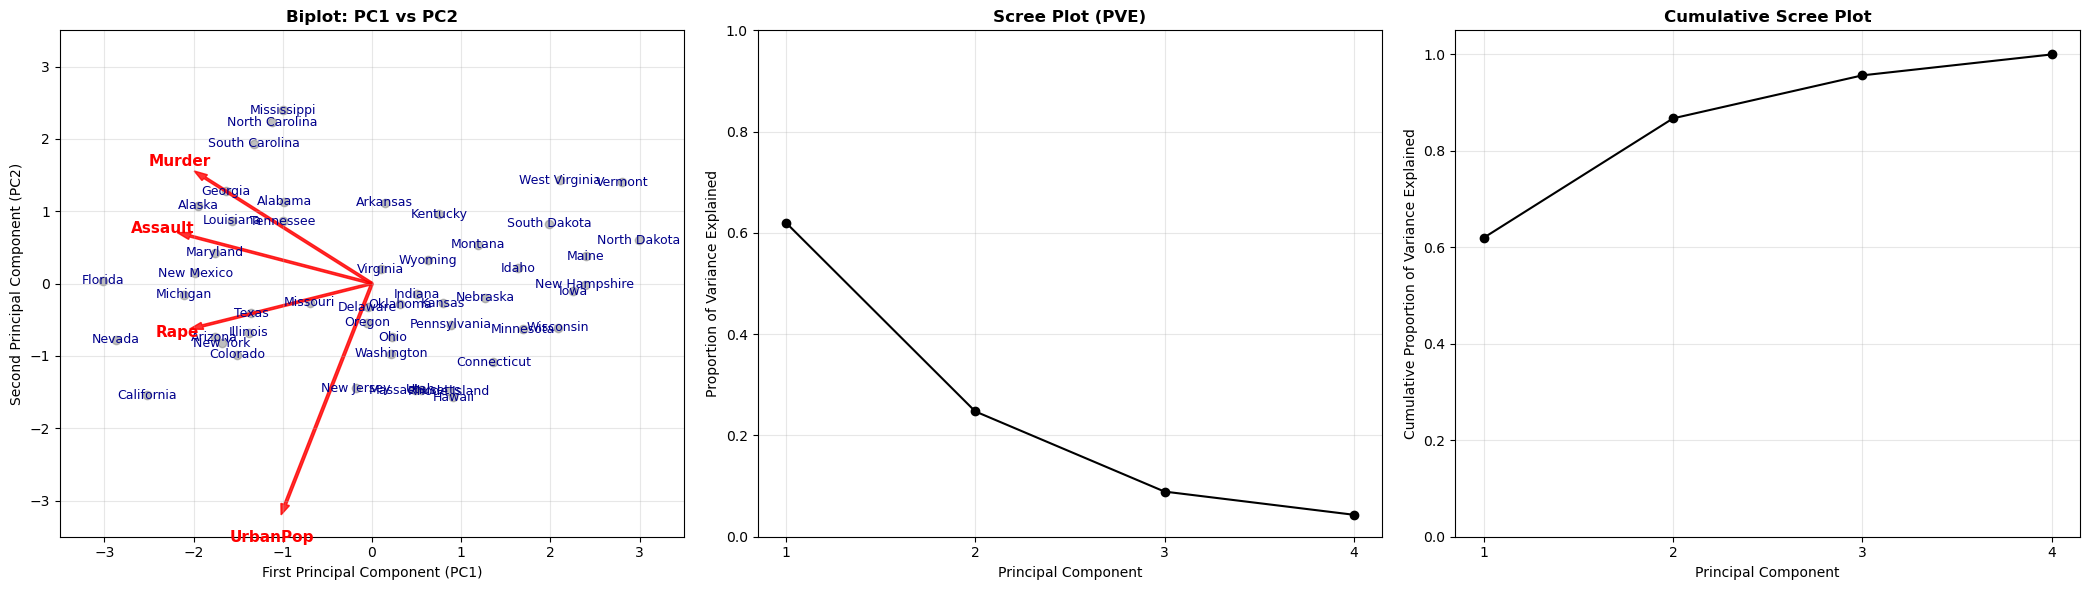

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load data USArrests
df = pd.read_csv("data/USArrests.csv", index_col=0)

print("Original features")
print(df.columns.tolist())

print("\nFeature Means")
print(df.mean().round(2))

print("\nFeature Variances")
print(df.var().round(1))

# 2. Standardizing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

loadings = -pca.components_.T
scores = -X_pca

components_names = [f'PC{i+1}' for i in range(pca.n_components_)]
df_loadings = pd.DataFrame(loadings, index=df.columns, columns=components_names)
df_scores = pd.DataFrame(scores, index=df.index, columns=components_names)

print("\nLoading matix (Loadings / Rotation) ---")
print(df_loadings.round(3))

print("\nScores Matrix Shape")
print(df_scores.shape)

# 3. PVE
sdev = np.sqrt(pca.explained_variance_)
print("\nStadnard deviation components (sdev)")
print(np.round(sdev, 3))

pve = pca.explained_variance_ratio_
print("\nPortion PVE")
for i, val in enumerate(pve, start=1):
    print(f"PC{i}: {val:.2%}")

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

ax1 = axes[0]
ax1.scatter(df_scores["PC1"], df_scores["PC2"], color="gray", alpha=0.5)
for state in df_scores.index:
    ax1.text(df_scores.loc[state, "PC1"], df_scores.loc[state, "PC2"], state, 
             fontsize=9, ha="center", va="center", color="darkblue")

scale_factor = 3.5
for feature in df_loadings.index:
    ax1.arrow(0, 0, df_loadings.loc[feature, "PC1"] * scale_factor, 
              df_loadings.loc[feature, "PC2"] * scale_factor, 
              color='red', width=0.03, head_width=0.1, alpha=0.8)
    ax1.text(df_loadings.loc[feature, "PC1"] * scale_factor * 1.15, 
             df_loadings.loc[feature, "PC2"] * scale_factor * 1.15, 
             feature, color='red', fontsize=11, weight="bold", ha="center", va="center")

ax1.set_xlabel("First Principal Component (PC1)")
ax1.set_ylabel("Second Principal Component (PC2)")
ax1.set_title("Biplot: PC1 vs PC2", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-3.5, 3.5)
ax1.set_ylim(-3.5, 3.5)
# График 2: Scree Plot (PVE)
ax2 = axes[1]
ax2.plot(range(1, 5), pve, marker='o', linestyle='-', color='black')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Proportion of Variance Explained')
ax2.set_title('Scree Plot (PVE)', fontsize=12, fontweight='bold')
ax2.set_xticks(range(1, 5))
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
ax3.plot(range(1, 5), np.cumsum(pve), marker='o', linestyle='-', color="black")
ax3.set_xlabel("Principal Component")
ax3.set_ylabel("Cumulative Proportion of Variance Explained")
ax3.set_title("Cumulative Scree Plot", fontsize=12, fontweight="bold")
ax3.set_xticks(range(1, 5))
ax3.set_ylim(0, 1.05)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

First Principal Component: Explains 62.01% of the total variance. It is heavily and almost equally weighted by crime-related variables: Assault (-0.583), Rape (-0.543), and Murder (-0.536). Since all these loadings are negative, PC1 effectively serves as a general index of overall crime rates, where lower (more negative) scores represent states with significantly higher crime levels

Second Principal Component (PC2): Explains 24.74% of the variance. It is overwhelmingly dominated by the UrbanPop variable with a strong negative loading of -0.873. Therefore, PC2 predominantly captures the level of urbanization of a state, with more negative scores indicating highly urbanized areas

When analyzing the biplot, observations must be interpreted in relation to the direction of the feature loading vectors (arrows):

- High Crime States: States located on the far left of the plot, such as California, Nevada, and Florida, align with the crime vectors and thus possess the highest crime rates per 100,000 residents.

- Low Crime States: Conversely, states on the far right, like North Dakota, South Dakota, and Iowa, have high positive PC1 scores, indicating very low rates of violent crime.


### 10.5 Clustering

K-MEANS WITH K = 2
Cluster assignments for the 50 observations:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1]

K-MEANS WITH K = 3
Cluster sizes:
Cluster 0: 21 observations
Cluster 1: 9 observations
Cluster 2: 20 observations

Cluster centers (centroids):
[[ 2.82805911 -4.11351797]
 [ 0.69945422 -2.14934345]
 [-0.27876523  0.51224152]]

Total Within-Cluster Sum of Squares (Inertia) for K=3: 68.9738

COMPARING N_INIT (EFFECT OF LOCAL OPTIMA)
Total Within-SS with n_init=1:  86.2557
Total Within-SS with n_init=20: 68.9738


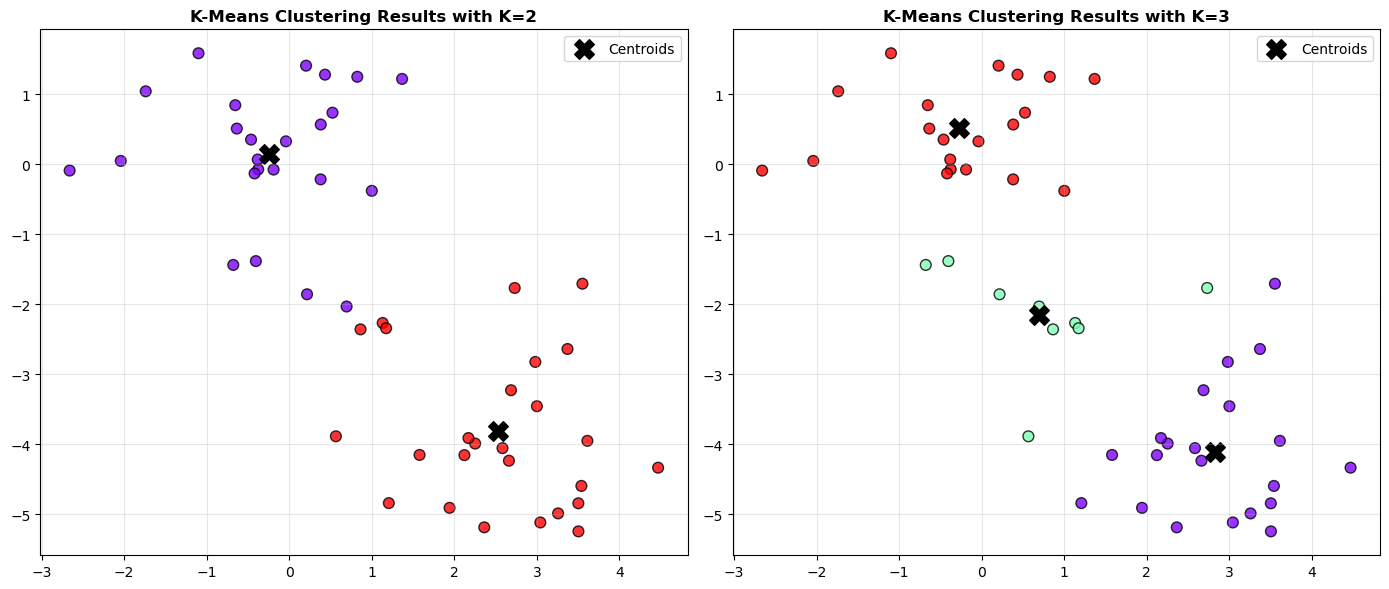

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Generate data
np.random.seed(2)
X = np.random.normal(size=(50, 2))

X[:25, 0] = X[:25, 0] + 3
X[:25, 1] = X[:25, 1] - 4

# 2. Clustering С K = 2
kmeans_k2 = KMeans(n_clusters=2, n_init=20, random_state=2)
kmeans_k2.fit(X)

print("K-MEANS WITH K = 2")
print("Cluster assignments for the 50 observations:")
print(kmeans_k2.labels_)

# 3. Clustering С K = 3
kmeans_k3 = KMeans(n_clusters=3, n_init=20, random_state=4)
kmeans_k3.fit(X)

print("\nK-MEANS WITH K = 3")
print("Cluster sizes:")
unique, counts = np.unique(kmeans_k3.labels_, return_counts=True)
for cluster_id, size in zip(unique, counts):
    print(f"Cluster {cluster_id}: {size} observations")

print("\nCluster centers (centroids):")
print(kmeans_k3.cluster_centers_)

print(f"\nTotal Within-Cluster Sum of Squares (Inertia) for K=3: {kmeans_k3.inertia_:.4f}")

# 4. Comparing N_INIT=1 AND N_INIT=20
kmeans_bad = KMeans(n_clusters=3, n_init=1, init="random", random_state=3)
kmeans_bad.fit(X)

print("\nCOMPARING N_INIT (EFFECT OF LOCAL OPTIMA)")
print(f"Total Within-SS with n_init=1:  {kmeans_bad.inertia_:.4f}")
print(f"Total Within-SS with n_init=20: {kmeans_k3.inertia_:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X[:, 0], X[:, 1], c=kmeans_k2.labels_, cmap="rainbow", s=60, edgecolors="k", alpha=0.8)
axes[0].scatter(kmeans_k2.cluster_centers_[:, 0], kmeans_k2.cluster_centers_[:, 1], 
                marker="X", c="black", s=200, label="Centroids")
axes[0].set_title("K-Means Clustering Results with K=2", fontsize=12, fontweight="bold")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].scatter(X[:, 0], X[:, 1], c=kmeans_k3.labels_, cmap="rainbow", s=60, edgecolors="k", alpha=0.8)
axes[1].scatter(kmeans_k3.cluster_centers_[:, 0], kmeans_k3.cluster_centers_[:, 1], 
                marker="X", c="black", s=200, label="Centroids")
axes[1].set_title("K-Means Clustering Results with K=3", fontsize=12, fontweight="bold")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

Clustering Performance and Local Optima (K=3):

- $\_init = 1$ Total Within-SS: 86.256

- $\_init = 20$ Total Within-SS: 68.974

Analysis: Performing clustering with only a single random initialization (n_init=1) led to an undesirable local optimum with a substantially higher objective function value. Increasing the number of initial configurations to 20 successfully found the global minimum (68.974), reinforcing the textbook recommendation to always utilize a high n_init value for stable and reproducible results.

Over-clustering Effect (K=3 vs True K=2):

When forced to partition the data into K=3 groups instead of the true K=2, the K-Means algorithm is mathematically constrained to minimize the within-cluster sum of squares by introducing an artificial decision boundary.

As visualized in the plot, the algorithm splits the two true underlying clusters by capturing the boundary observations located in the overlapping zone. The intermediate cluster (Centroid: $[0.70, -2.15]$) essentially groups together these bridge points and potential outliers, demonstrating that without domain knowledge or cross-validation techniques (like the Elbow method), K-Means will blindly force structure onto data even where none exists.

### 10.5.2 Hierarchical Clustering

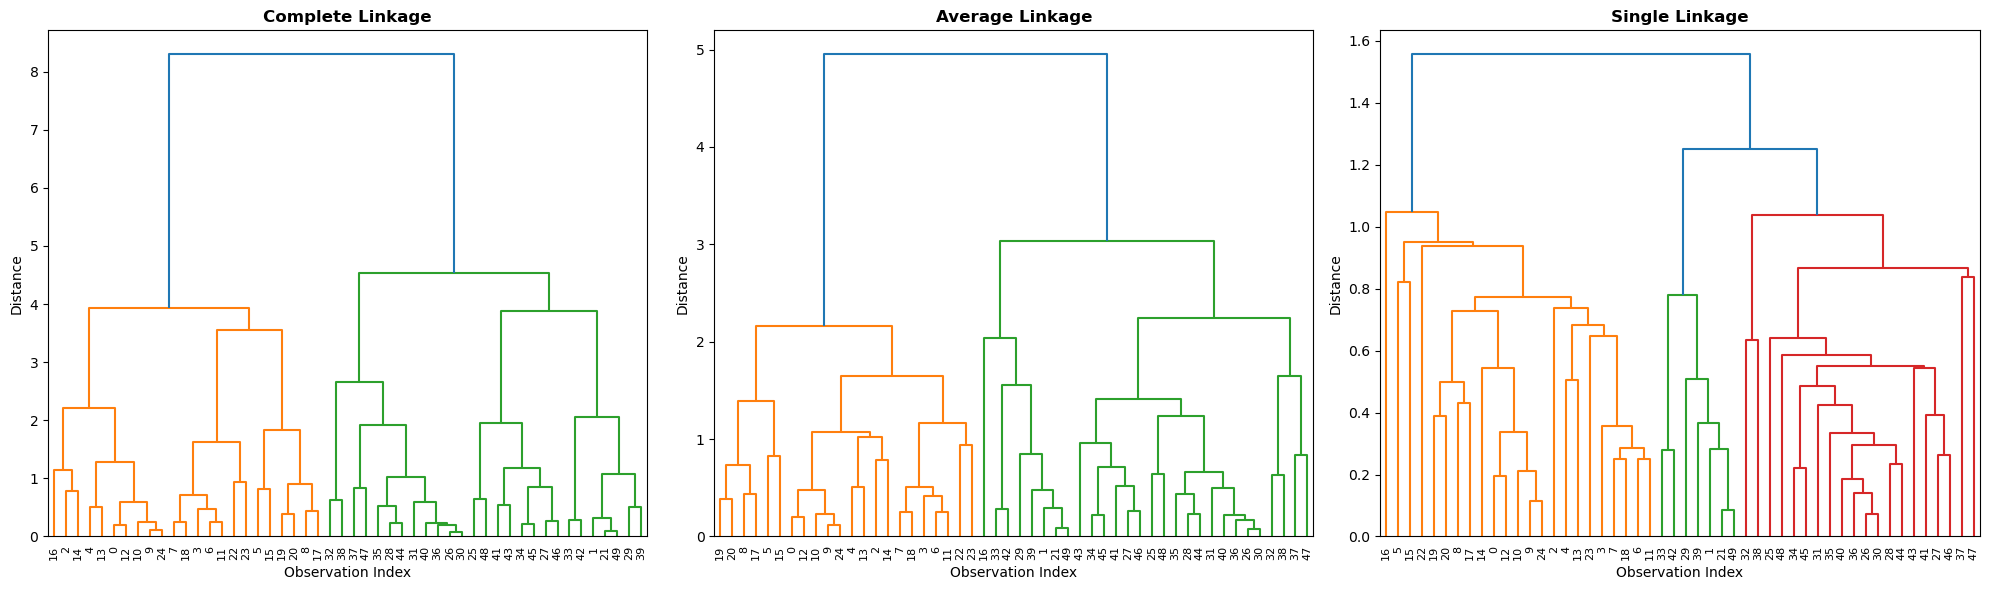

CLUSTER LABELS AT K = 2
Complete Linkage:
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]

Average Linkage:
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]

Single Linkage:
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]

SINGLE LINKAGE AT K = 4
Single Linkage (K=4):
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 1 0 0 0 3 3 3 3 1 3 3 3 1 3 3 3
 3 3 1 3 3 1 3 3 3 3 3 3 1]


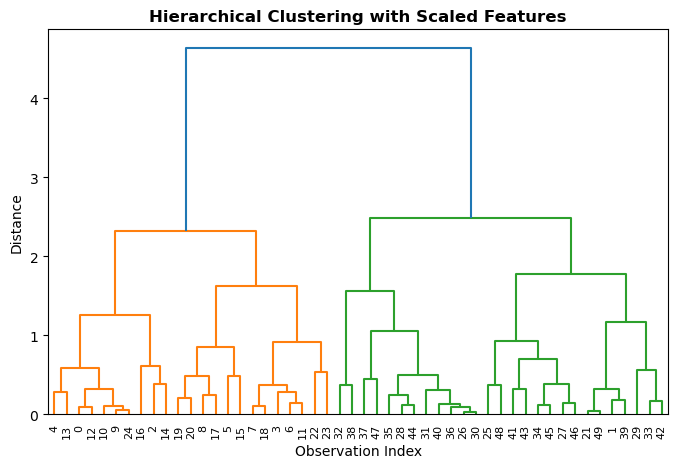

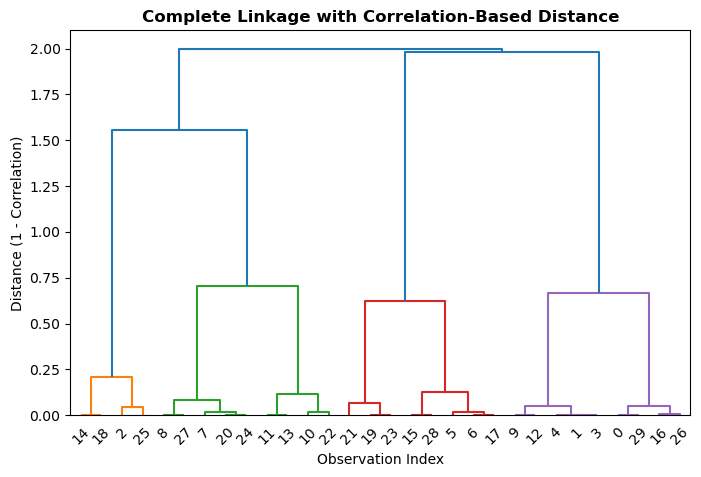

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler

np.random.seed(2)
X = np.random.normal(size=(50, 2))
X[:25, 0] += 3
X[:25, 1] -= 4

# 1. Construct clustering
hc_complete = linkage(X, method="complete", metric="euclidean")
hc_average = linkage(X, method="average", metric="euclidean")
hc_single = linkage(X, method="single", metric="euclidean")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

dendrogram(hc_complete, ax=axes[0])
axes[0].set_title("Complete Linkage", fontsize=12, fontweight="bold")

dendrogram(hc_average, ax=axes[1])
axes[1].set_title("Average Linkage", fontsize=12, fontweight="bold")

dendrogram(hc_single, ax=axes[2])
axes[2].set_title("Single Linkage", fontsize=12, fontweight="bold")

for ax in axes:
    ax.set_xlabel("Observation Index")
    ax.set_ylabel("Distance")

plt.tight_layout()
plt.show()

# 3. cut_tree
print("CLUSTER LABELS AT K = 2")
labels_complete = cut_tree(hc_complete, n_clusters=2).flatten()
labels_average = cut_tree(hc_average, n_clusters=2).flatten()
labels_single = cut_tree(hc_single, n_clusters=2).flatten()

print("Complete Linkage:\n", labels_complete)
print("\nAverage Linkage:\n", labels_average)
print("\nSingle Linkage:\n", labels_single)

print("\nSINGLE LINKAGE AT K = 4")
labels_single_k4 = cut_tree(hc_single, n_clusters=4).flatten()
print("Single Linkage (K=4):\n", labels_single_k4)

# 4. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
hc_scaled_complete = linkage(X_scaled, method="complete", metric="euclidean")

plt.figure(figsize=(8, 5))
dendrogram(hc_scaled_complete)
plt.title("Hierarchical Clustering with Scaled Features", fontsize=12, fontweight="bold")
plt.xlabel("Observation Index")
plt.ylabel("Distance")
plt.show()

# 5. Correlation-Based Distance
np.random.seed(42)
X_3d = np.random.normal(size=(30, 3))

dist_correlation = pdist(X_3d, metric="correlation")
hc_correlation = linkage(dist_correlation, method="complete")

plt.figure(figsize=(8, 5))
dendrogram(hc_correlation)
plt.title("Complete Linkage with Correlation-Based Distance", fontsize=12, fontweight="bold")
plt.xlabel("Observation Index")
plt.ylabel("Distance (1 - Correlation)")
plt.show()

Complete and Average Linkages: Both methods successfully and cleanly separate the 50 observations into well-balanced, distinct structural branches on the dendrogram. This occurs because Complete linkage minimizes the maximum cluster diameter, while Average linkage considers pairwise mean distances, both preventing premature cluster merging.

Single Linkage (The Chaining Effect): In contrast, Single linkage demonstrates a textbook case of the chaining effect. Because it defines inter-cluster dissimilarity based on the single closest pair of points, it tends to iteratively pull single trailing observations into one massive, continuous cluster rather than creating symmetrical partitions. Even when cutting the tree at K=4, Single linkage isolates unique boundary singletons into tiny individual groups while leaving the vast majority of data points trapped inside a single overarching cluster.

Impact of Scaling and Distance Metrics:

- Feature Scaling: Standardizing the simulated features alters the inter-observation Euclidean distances, producing a more standardized height distribution across the branches.

- Correlation-Based Distance: Utilizing 1 - \text{Correlation} as a dissimilarity metric switches the focus from the physical distance between coordinates to the shape of the feature profiles across profiles. This approach is vital when the absolute magnitude of data matters less than the highly synchronized directional trends among variables

### 10.6 NCI60 Data Example
### 10.6.1 PCA on the NCI60 Data

Data shape: 64 rows, 6830 columns

First 4 measures: ['CNS' 'CNS' 'CNS' 'RENAL']

Distribution data set
labs
RENAL          9
NSCLC          9
MELANOMA       8
BREAST         7
COLON          7
OVARIAN        6
LEUKEMIA       6
CNS            5
PROSTATE       2
UNKNOWN        1
K562B-repro    1
K562A-repro    1
MCF7A-repro    1
MCF7D-repro    1
Name: count, dtype: int64


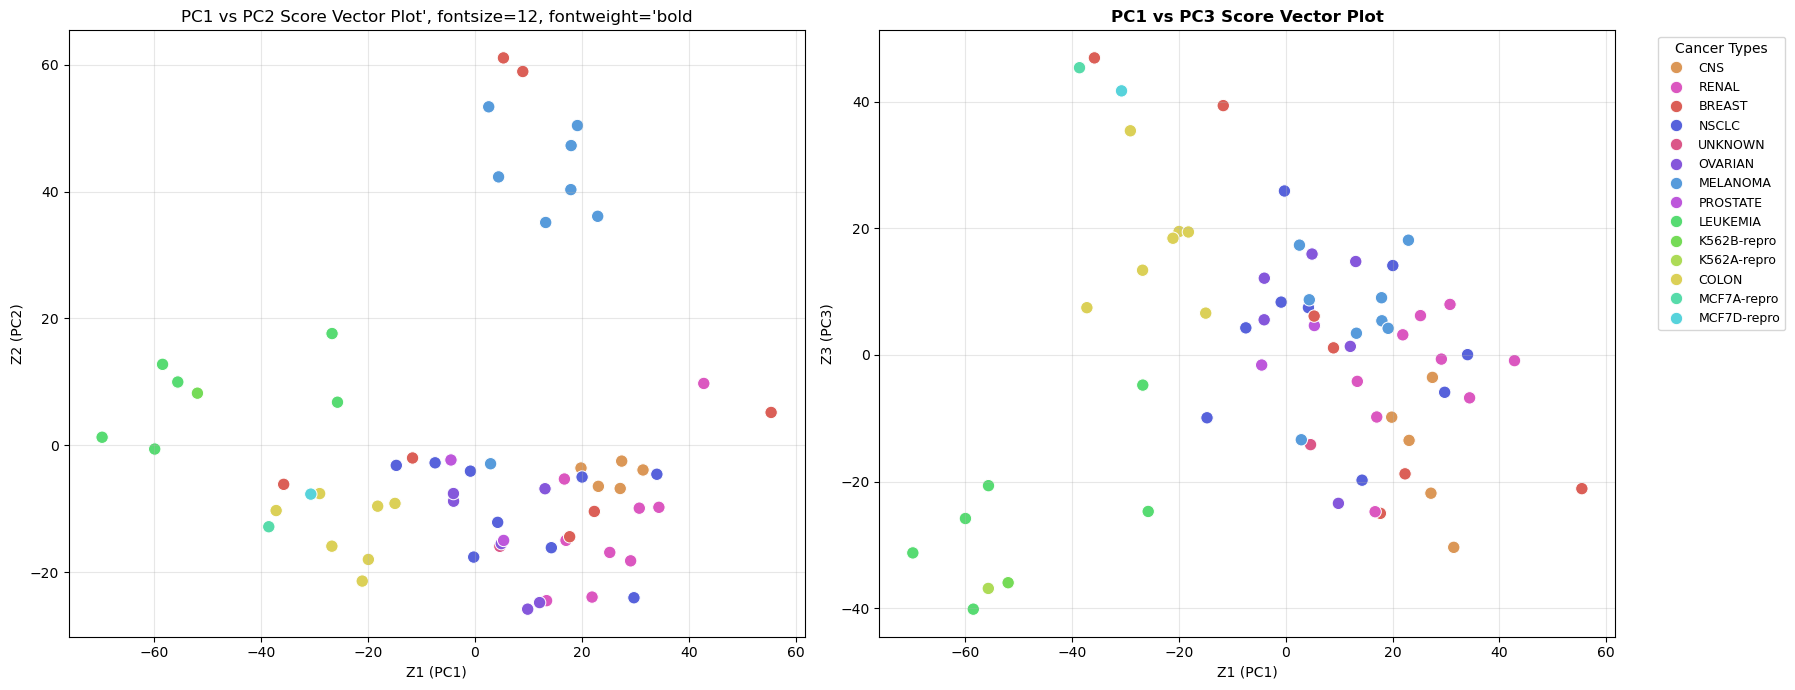


Importance of Components
     Standard deviation  Proportion of Variance (%)  Cumulative Proportion (%)
PC1              28.074                      11.359                     11.359
PC2              21.651                       6.756                     18.115
PC3              19.977                       5.752                     23.867
PC4              17.167                       4.248                     28.115
PC5              16.098                       3.735                     31.850


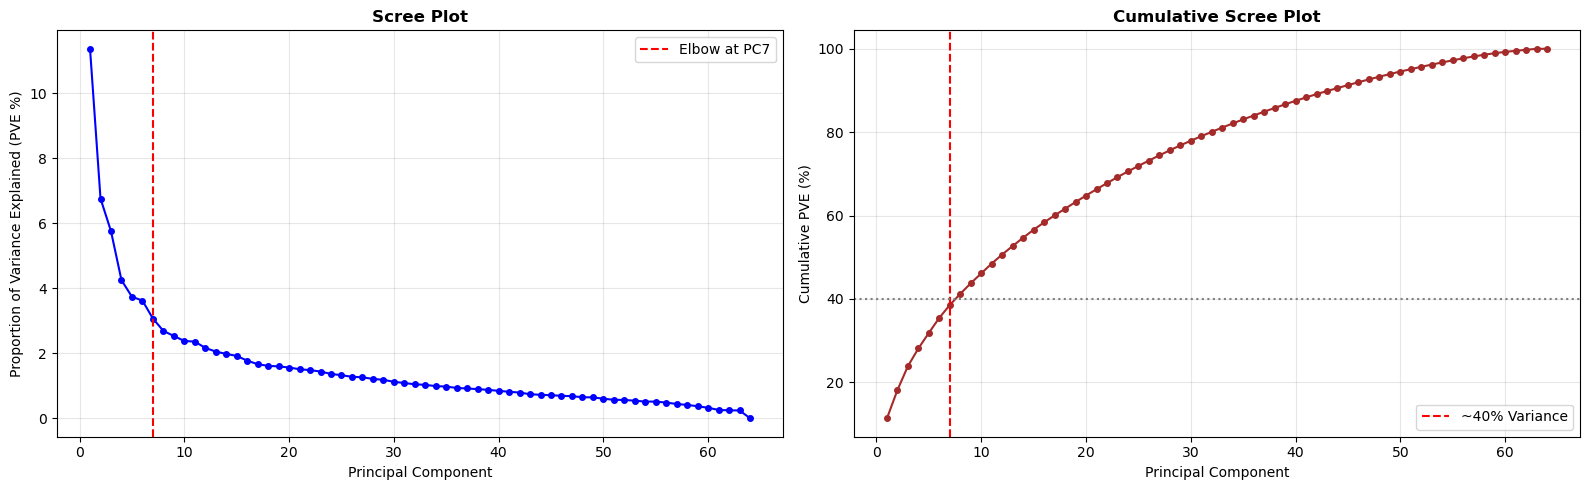

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load data and exploratory data analysis
data = pd.read_csv("data/NCI60.csv", index_col=0)

X_raw = data.drop(columns=["labs"])
y_labs = data[["labs"]]
nci_labs = y_labs['labs'].values

print(f"Data shape: {X_raw.shape[0]} rows, {X_raw.shape[1]} columns")
print("\nFirst 4 measures:", nci_labs[:4])

print("\nDistribution data set")
print(y_labs["labs"].value_counts())

# 2. Scaling and PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

pc_cols = [f"PC{i+1}" for i in range(pca.n_components_)]
df_pca = pd.DataFrame(X_pca, columns=pc_cols)
df_pca["CancerType"] = nci_labs

unique_types = np.unique(nci_labs)
palette = sns.color_palette("hls", len(unique_types))
color_map = dict(zip(unique_types, palette))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="CancerType", 
                palette=color_map, s=80, ax=axes[0], legend=False)
axes[0].set_xlabel("Z1 (PC1)")
axes[0].set_ylabel("Z2 (PC2)")
axes[0].set_title("PC1 vs PC2 Score Vector Plot', fontsize=12, fontweight='bold")
axes[0].grid(True, alpha=0.3)

sns.scatterplot(data=df_pca, x="PC1", y="PC3", hue="CancerType", 
                palette=color_map, s=80, ax=axes[1])
axes[1].set_xlabel("Z1 (PC1)")
axes[1].set_ylabel("Z3 (PC3)")
axes[1].set_title("PC1 vs PC3 Score Vector Plot", fontsize=12, fontweight="bold")
axes[1].grid(True, alpha=0.3)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Cancer Types", fontsize=9)

plt.tight_layout()
plt.show()

# 4. PVE
pve = pca.explained_variance_ratio_ * 100
cumulative_pve = np.cumsum(pve)

print("\nImportance of Components")
summary_df = pd.DataFrame({
    "Standard deviation": np.sqrt(pca.explained_variance_[:5]),
    "Proportion of Variance (%)": pve[:5],
    "Cumulative Proportion (%)": cumulative_pve[:5]
}, index=[f'PC{i+1}' for i in range(5)])
print(summary_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(range(1, len(pve) + 1), pve, marker="o", color="blue", linestyle="-", markersize=4)
axes[0].axvline(x=7, color="red", linestyle="--", label="Elbow at PC7")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Proportion of Variance Explained (PVE %)")
axes[0].set_title("Scree Plot", fontsize=12, fontweight="bold")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(range(1, len(cumulative_pve) + 1), cumulative_pve, marker="o", color="brown", linestyle="-", markersize=4)
axes[1].axvline(x=7, color="red", linestyle="--", label="~40% Variance")
axes[1].axhline(y=40, color="gray", linestyle=":")
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Cumulative PVE (%)")
axes[1].set_title("Cumulative Scree Plot", fontsize=12, fontweight="bold")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

Variance Distribution: The first principal component (PC1) captures 11.36% of the total variance, followed by PC2 with 6.76%, and PC3 with 5.75%. Collectively, the first five components account for 31.85% of the dataset's total variance.

Elbow Criterion: As visualized in the Scree Plot, a distinct "elbow" or flattening occurs around the 7th principal component, where the cumulative explained variance reaches approximately 40%. This suggests that the remaining components capture minor structural noise or gene-specific variations, validating the choice to focus analysis on the first few score vectors.

Unsupervised Class Separation: When projecting the 64 cell lines onto the PC1 vs PC2 and PC1 vs PC3 subspaces, observations belonging to identical cancer diagnoses demonstrate prominent spatial clustering.

Distinct Profiles: Notably, Leukemia cell lines (represented in bright green) cluster distinctly on the far left of the PC1 axis, revealing a gene expression profile that heavily contrasts with solid tumors. Similarly, Melanoma lines form a tight, isolated cluster along the upper section of the PC2 axis.

Conclusion: This strong visual alignment confirms that unsupervised PCA successfully extracts meaningful, low-dimensional biological signal from high-dimensional genomic microarrays without utilizing any prior clinical labeling during training.

### 10.6.2 Clustering the Observations of the NCI60 Data

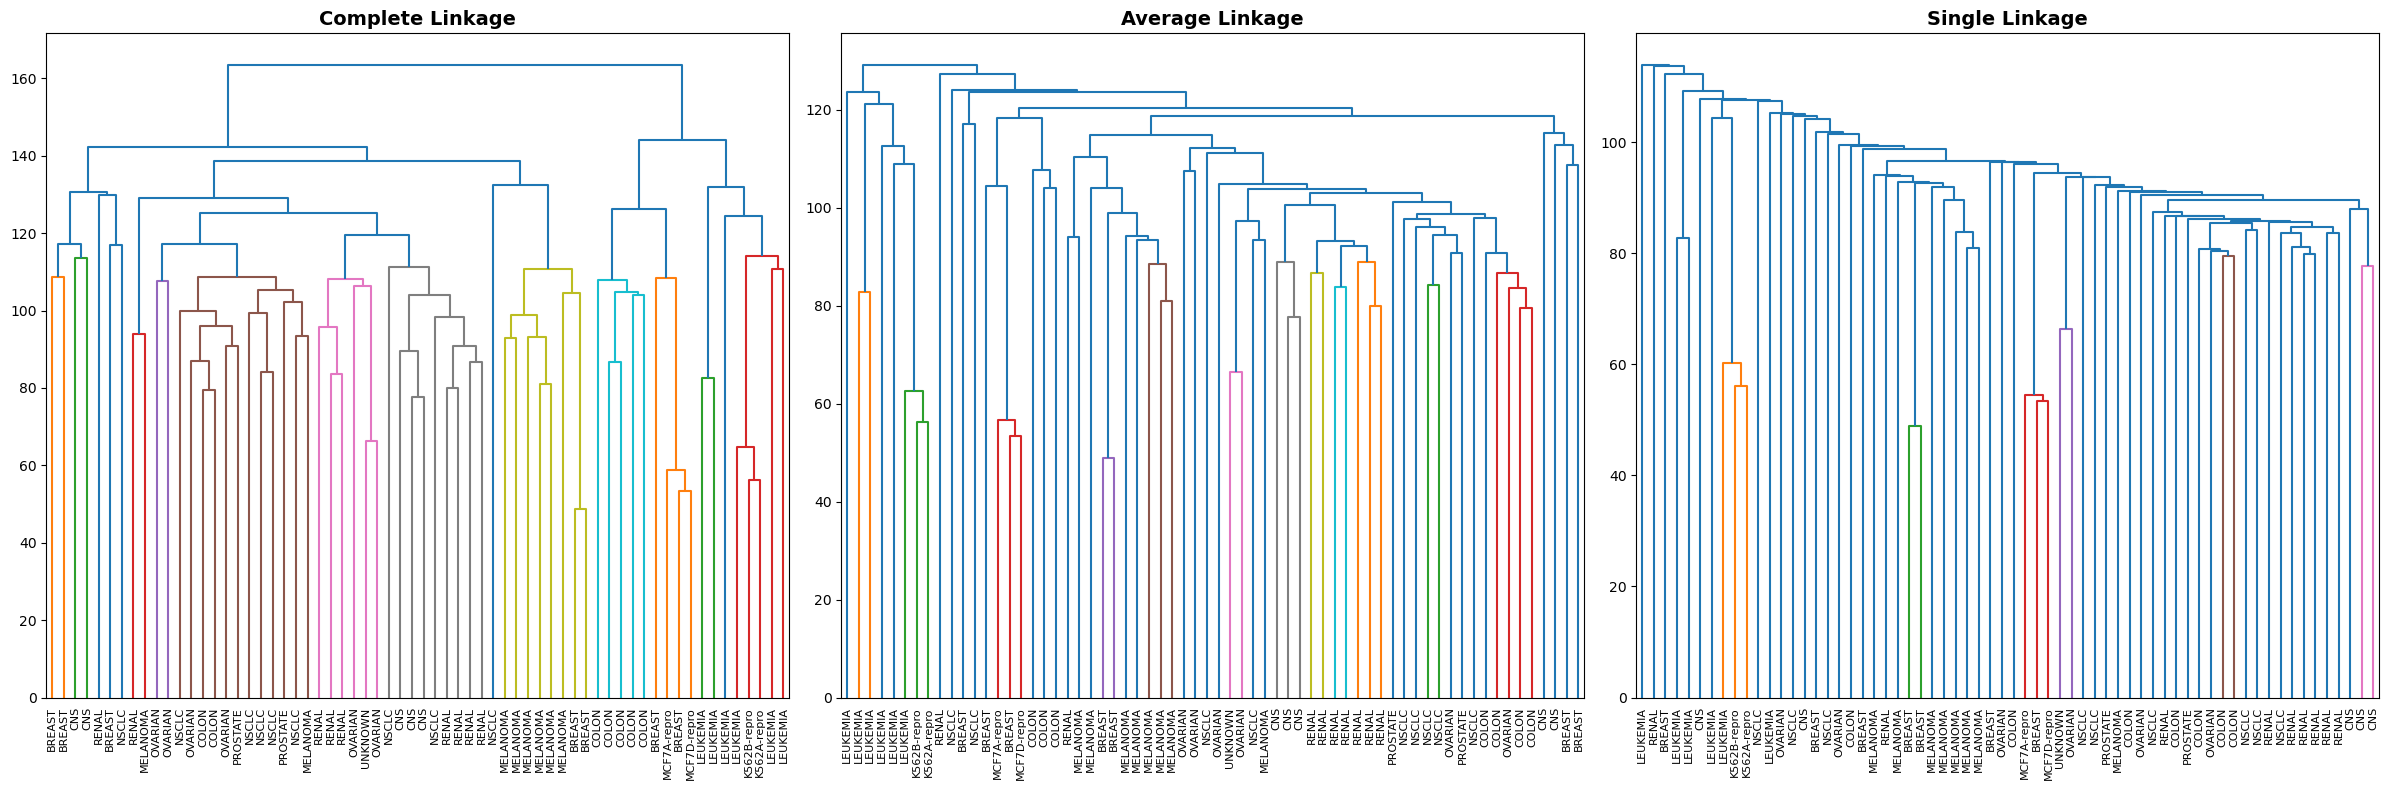

HIERARCHICAL CLUSTERS VS CANCER TYPES
Cancer Type  BREAST  CNS  COLON  K562A-repro  K562B-repro  LEUKEMIA  \
row_0                                                                 
Cluster 1         2    3      2            0            0         0   
Cluster 2         3    2      0            0            0         0   
Cluster 3         0    0      0            1            1         6   
Cluster 4         2    0      5            0            0         0   

Cancer Type  MCF7A-repro  MCF7D-repro  MELANOMA  NSCLC  OVARIAN  PROSTATE  \
row_0                                                                       
Cluster 1              0            0         8      8        6         2   
Cluster 2              0            0         0      1        0         0   
Cluster 3              0            0         0      0        0         0   
Cluster 4              1            1         0      0        0         0   

Cancer Type  RENAL  UNKNOWN  
row_0                        
Cluster 1   

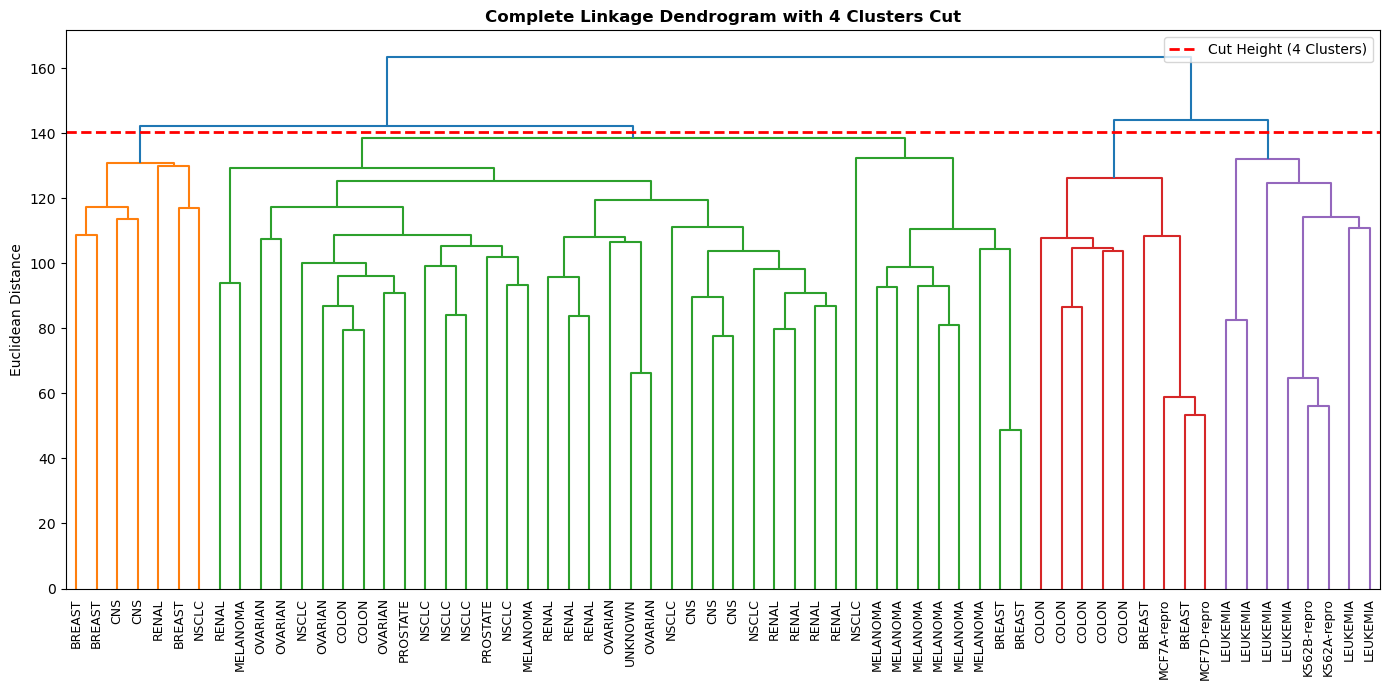


 K-MEANS VS HIERARCHICAL
Hierarchical   1  2  3  4
K-Means                  
1              0  0  8  0
2             11  7  0  0
3             20  0  0  9
4              9  0  0  0

PCA + HIERARCHICAL (K=4) VS CANCER TYPES
Cancer Type  BREAST  CNS  COLON  K562A-repro  K562B-repro  LEUKEMIA  \
row_0                                                                 
Cluster 1         0    2      7            0            0         2   
Cluster 2         5    3      0            0            0         0   
Cluster 3         0    0      0            1            1         4   
Cluster 4         2    0      0            0            0         0   

Cancer Type  MCF7A-repro  MCF7D-repro  MELANOMA  NSCLC  OVARIAN  PROSTATE  \
row_0                                                                       
Cluster 1              0            0         1      8        5         2   
Cluster 2              0            0         7      1        1         0   
Cluster 3              0            0    

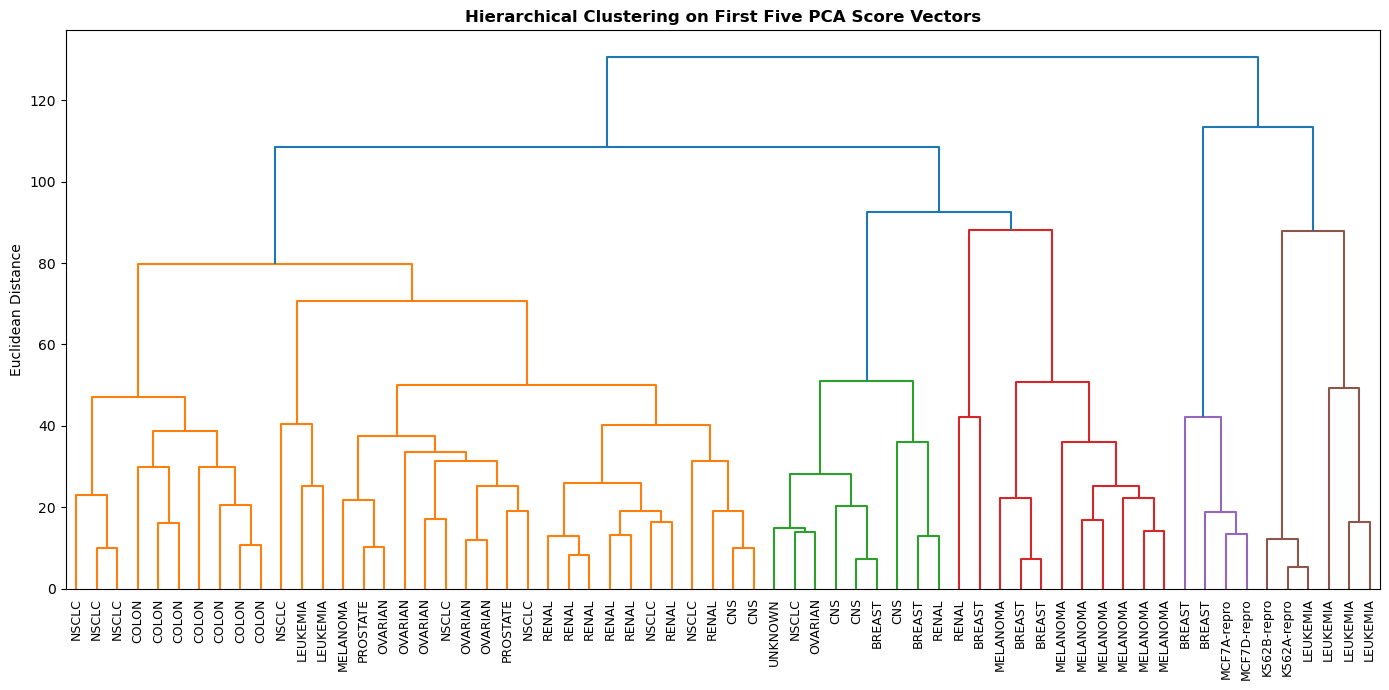

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ (Повторяем шаг из предыдущей задачи)
# =========================================================================
data = pd.read_csv("data/NCI60.csv", index_col=0)
X_raw = data.drop(columns=["labs"])
nci_labs =data["labs"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

hc_complete = linkage(X_scaled, method="complete", metric="euclidean")
hc_average = linkage(X_scaled, method="average", metric="euclidean")
hc_single = linkage(X_scaled, method="single", metric="euclidean")

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Complete Linkage
dendrogram(hc_complete, labels=nci_labs, orientation='top', leaf_rotation=90, leaf_font_size=8, ax=axes[0])
axes[0].set_title("Complete Linkage", fontsize=14, fontweight='bold')

# Average Linkage
dendrogram(hc_average, labels=nci_labs, orientation="top", leaf_rotation=90, leaf_font_size=8, ax=axes[1])
axes[1].set_title("Average Linkage", fontsize=14, fontweight="bold")

# Single Linkage
dendrogram(hc_single, labels=nci_labs, orientation="top", leaf_rotation=90, leaf_font_size=8, ax=axes[2])
axes[2].set_title("Single Linkage", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

hc_clusters = cut_tree(hc_complete, n_clusters=4).flatten()

print("HIERARCHICAL CLUSTERS VS CANCER TYPES")
ct_hierarchical = pd.crosstab(index=f"Cluster " + pd.Series(hc_clusters + 1).astype(str), 
                              columns=nci_labs, 
                              colnames=["Cancer Type"])
print(ct_hierarchical)

plt.figure(figsize=(14, 7))
heights = hc_complete[:, 2]
cut_height = (heights[-3] + heights[-4]) / 2

dendrogram(hc_complete, labels=nci_labs, leaf_rotation=90, leaf_font_size=9, color_threshold=cut_height)
plt.axhline(y=cut_height, color="red", linestyle="--", linewidth=2, label=f"Cut Height (4 Clusters)")
plt.title("Complete Linkage Dendrogram with 4 Clusters Cut", fontsize=12, fontweight="bold")
plt.ylabel("Euclidean Distance")
plt.legend()
plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=4, n_init=20, random_state=2)
km_clusters = kmeans.fit_transform(X_scaled)
km_labels = kmeans.labels_
print("\n K-MEANS VS HIERARCHICAL")
comparison_table = pd.crosstab(index=pd.Series(km_labels + 1, name="K-Means"), 
                               columns=pd.Series(hc_clusters + 1, name="Hierarchical"))
print(comparison_table)

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

hc_pca = linkage(X_pca, method="complete", metric="euclidean")
hc_pca_clusters = cut_tree(hc_pca, n_clusters=4).flatten()

print("\nPCA + HIERARCHICAL (K=4) VS CANCER TYPES")
ct_pca_hierarchical = pd.crosstab(index=f"Cluster " + pd.Series(hc_pca_clusters + 1).astype(str), 
                                  columns=nci_labs, 
                                  colnames=["Cancer Type"])
print(ct_pca_hierarchical)

plt.figure(figsize=(14, 7))
dendrogram(hc_pca, labels=nci_labs, leaf_rotation=90, leaf_font_size=9)
plt.title("Hierarchical Clustering on First Five PCA Score Vectors", fontsize=12, fontweight="bold")
plt.ylabel("Euclidean Distance")
plt.tight_layout()
plt.show()